In [1]:
import os
import sys
import torch

sys.path.append(os.path.abspath(".."))
import seismic_facies.models.diff_model as dm
from seismic_facies.procs.helper import set_seed, select_device
from seismic_facies.procs import dataset, dataloader
from seismic_facies.viz import viz_diff
from seismic_facies.models import metrics

In [2]:
set_seed(42)
device = select_device()

No GPU available!


Instantiate the model

In [3]:
embed_dim, alphas, alphas_bar, betas, T = dm.utils.get_diff_model_params(dim=64, T=1000)
embed_dim, alphas.shape, alphas_bar.shape, betas.shape, T

(64, torch.Size([1000]), torch.Size([1000]), torch.Size([1000]), 1000)

In [4]:
diff_model = dm.models.DiffUnet(in_channels=6, out_channels=6, cond_channels=1, embed_dim=embed_dim * 4).to(device)
diff_model

DiffUnet(
  (embed): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (e1): EncBlock(
    (conv_block1): ConvBlock(
      (conv): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (dense): Linear(in_features=256, out_features=32, bias=True)
      (bn): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
    (conv_block2): ConvBlock(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (dense): Linear(in_features=256, out_features=32, bias=True)
      (bn): GroupNorm(8, 32, eps=1e-05, affine=True)
      (act): GELU(approximate='none')
    )
    (pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (e2): EncBlock(
    (conv_block1): ConvBlock(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), s

Load pretrained weight

In [5]:
model_save_name = 'diff_model_seis_class_FIX.pt'           # .pt and .pth are common file extensions for saving models in pytorch
weights_dir = os.path.join(os.path.abspath('..'), 'seismic_facies/data')
data_path = os.path.join(weights_dir, model_save_name)
diff_model.load_state_dict(torch.load(data_path, map_location=device))

<All keys matched successfully>

Make test dataset and dataloader

In [6]:
data_path = 'test_once/test1_seismic.npy'
label_path = 'test_once/test1_labels.npy'

In [7]:
test_dataset = dataset.SeismicSliceDataset(seismic_path=data_path, labels_path=label_path, mode="both")
test_dataset

In [8]:
batch_size = 12
test_loader = dataloader.create_dataloader_with_direction_batches(test_dataset, batch_size)
test_loader

See Inference result

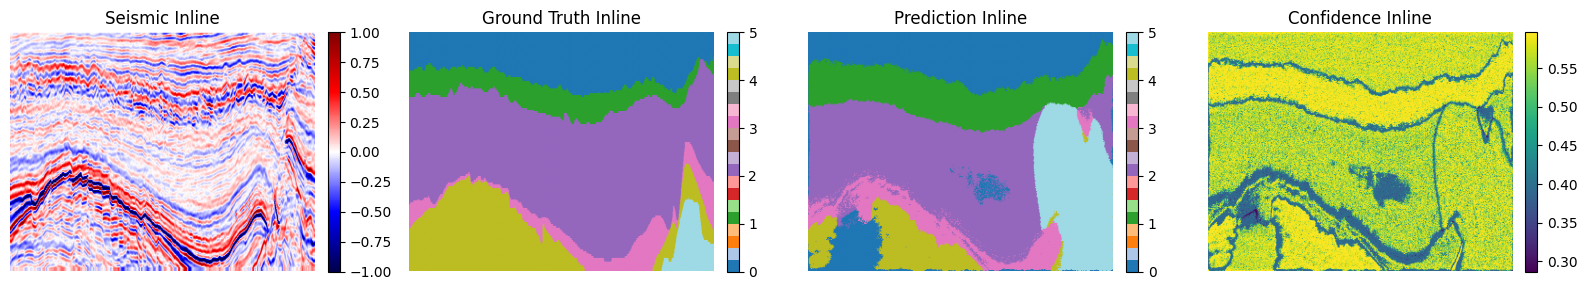

In [9]:
viz_diff.plot_segmentation_batch_diff(
    model=diff_model,
    data_loader=test_loader,
    device=device,
    T=T,
    batch_idx=10,
    n_samples=1,
    betas=betas,
    alphas=alphas,
    alphas_bar=alphas_bar
)

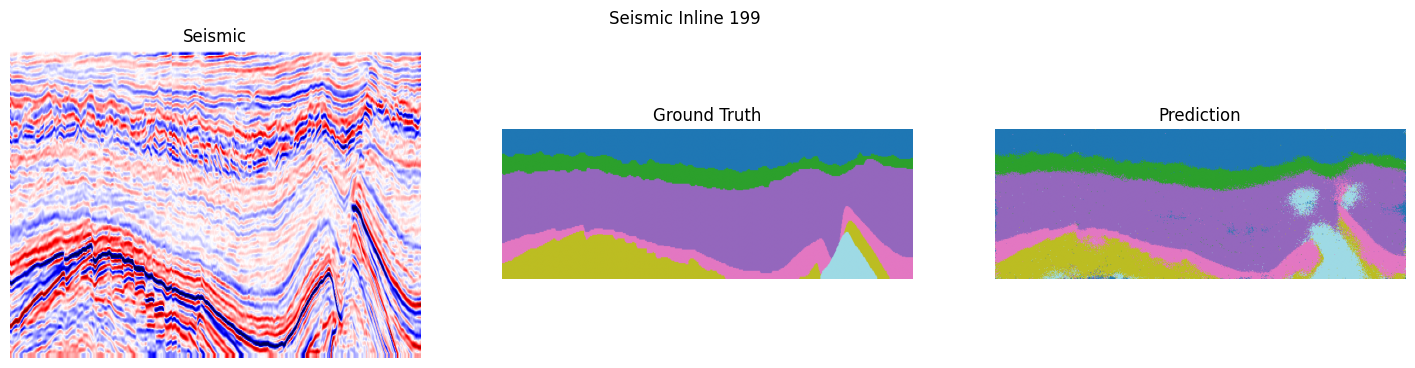

In [10]:
il_to_plot = 199
tp_to_plot = "Inline"
viz_diff.plot_sample_by_index_diff(diff_model, test_dataset, device, idx=il_to_plot, alphas=alphas, alphas_bar=alphas_bar, betas=betas, T=T, title=f"Seismic {tp_to_plot} {il_to_plot}")

See the metrics & performance of model

In [ ]:
scores, cls_iou = metrics.evaluate_metrics_diff_ddim(
    model=diff_model,
    data_loader=test_loader,
    device=device,
    n_classes=6,
    steps=50,        
    max_batches=None,
    alphas_bar=alphas_bar,
    fix_batch=dm.utils.fix_batch,
    T=T
)

In [ ]:
print(f"Pixel Acc: {scores["Pixel Acc"]}")
print("Class Acc: ")
for i in range(scores["Class Accuracy"].shape[0]):
    print(f"Class {i} Acc: {scores["Class Accuracy"][i]}")
print(f"Mean Class Acc: {scores["Mean Class Acc"]}")
print(f"Freq Weighted IoU: {scores["Freq Weighted IoU"]}")
print(f"Mean IoU: {scores["Mean IoU"]}")
print("Per-class IoU:")
for k, v in cls_iou.items():
    print(f"Class {k} IoU: {v}")

Pixel Acc: 0.8087208749405611
Class Acc: 
Class 0 Acc: 0.947351642654975
Class 1 Acc: 0.8860095499679674
Class 2 Acc: 0.9124639094775742
Class 3 Acc: 0.8305196460273762
Class 4 Acc: 0.33338116171734294
Class 5 Acc: 0.7386523018483934
Mean Class Acc: 0.7747297019489382
Freq Weighted IoU: 0.6878915444412168
Mean IoU: 0.5722392925367764
Per-class IoU:
Class 0 IoU: 0.7179826206366978
Class 1 IoU: 0.6917110376611221
Class 2 IoU: 0.8535926362081172
Class 3 IoU: 0.5251064171583107
Class 4 IoU: 0.3193489132376184
Class 5 IoU: 0.3256941303187922


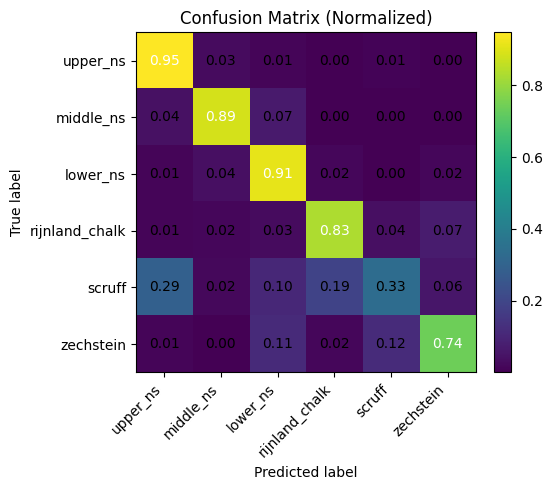

In [15]:
class_names = ['upper_ns', 'middle_ns', 'lower_ns',
                   'rijnland_chalk', 'scruff', 'zechstein']

cm = scores["confusion_matrix"]
metrics.plot_confusion_matrix(cm, class_names=class_names, normalize=True)